In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [31]:
# 0. Load Data
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE) # nếu shuffle/sample

BASE_DIR = os.getcwd() 
DATA_PATH = os.path.join(BASE_DIR, "dataset", "house_price_regression_dataset.csv")      

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(1000, 8)


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [3]:
# 1. Understand Data
print("Dtype :",df.dtypes)
print("So gia tri thieu :", df.isnull().sum())
print("so dong trung lap :", df.duplicated().sum())

Dtype : Square_Footage            int64
Num_Bedrooms              int64
Num_Bathrooms             int64
Year_Built                int64
Lot_Size                float64
Garage_Size               int64
Neighborhood_Quality      int64
House_Price             float64
dtype: object
So gia tri thieu : Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64
so dong trung lap : 0


In [15]:
# 2. Train / test split
TARGET = "House_Price"  
df_train, df_test = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)
print(f"df_train shape: {df_train.shape}")
print(f"df_test  shape: {df_test.shape}")

df_train shape: (800, 8)
df_test  shape: (200, 8)



Thống kê mô tả (df_train):
       Square_Footage  Num_Bedrooms  Num_Bathrooms   Year_Built    Lot_Size  \
count      800.000000    800.000000     800.000000   800.000000  800.000000   
mean      2813.900000      2.968750       1.971250  1986.902500    2.772345   
std       1252.769853      1.421372       0.816245    20.809536    1.283141   
min        503.000000      1.000000       1.000000  1950.000000    0.514134   
25%       1746.750000      2.000000       1.000000  1969.000000    1.689746   
50%       2855.500000      3.000000       2.000000  1987.000000    2.808737   
75%       3858.750000      4.000000       3.000000  2005.000000    3.876730   
max       4999.000000      5.000000       3.000000  2022.000000    4.989303   

       Garage_Size  Neighborhood_Quality   House_Price  
count   800.000000             800.00000  8.000000e+02  
mean      1.015000               5.59625  6.185761e+05  
std       0.820437               2.91528  2.534872e+05  
min       0.000000              

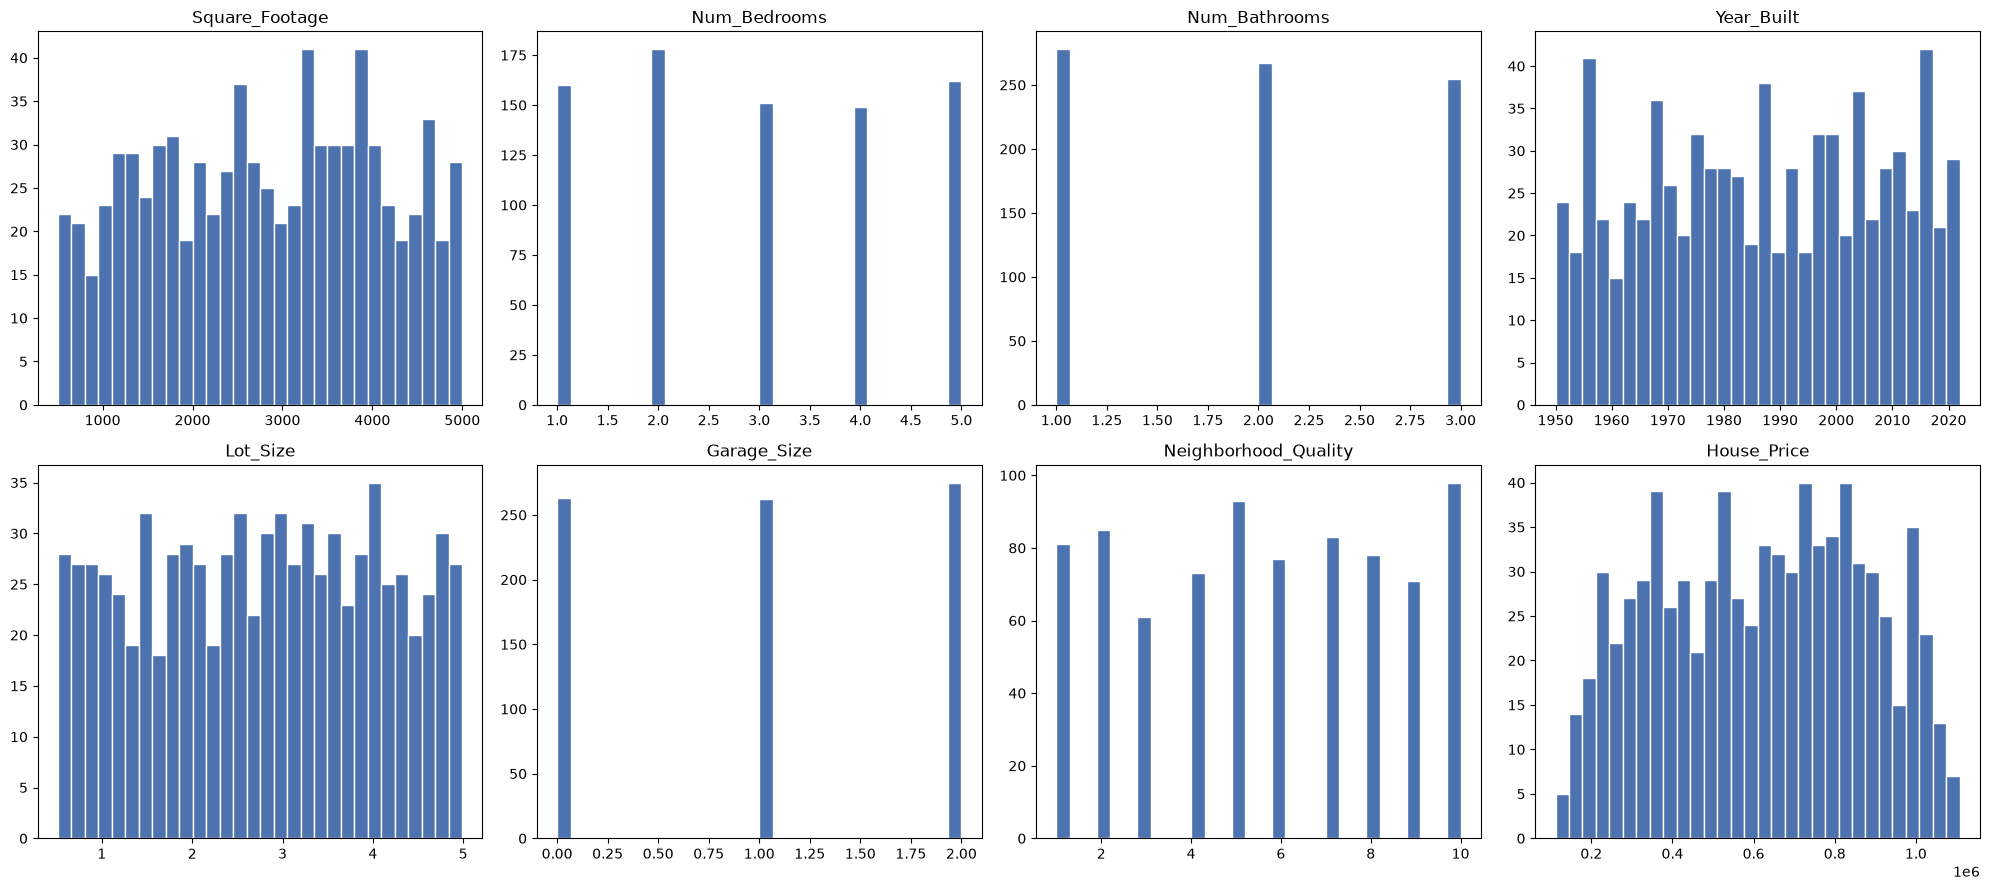

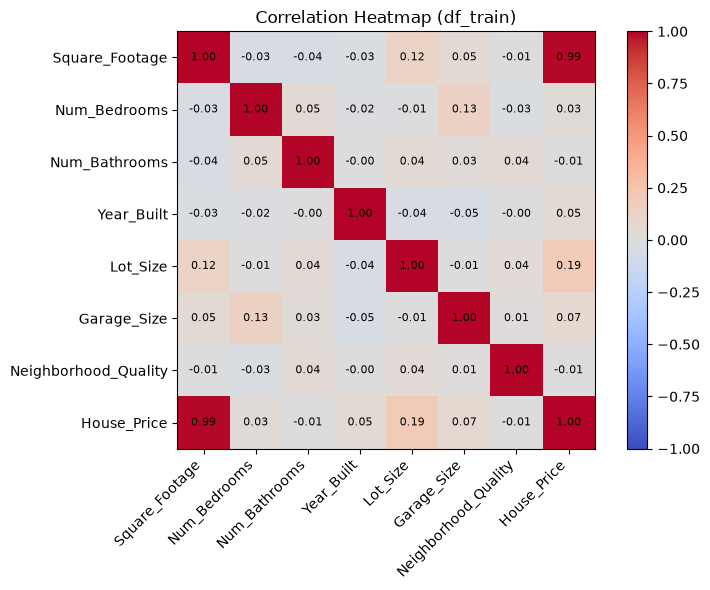


Kiểm tra outlier bằng ngưỡng IQR (chỉ xem, chưa xử lý):
  Square_Footage        : 0 outlier(s) theo IQR
  Num_Bedrooms          : 0 outlier(s) theo IQR
  Num_Bathrooms         : 0 outlier(s) theo IQR
  Year_Built            : 0 outlier(s) theo IQR
  Lot_Size              : 0 outlier(s) theo IQR
  Garage_Size           : 0 outlier(s) theo IQR
  Neighborhood_Quality  : 0 outlier(s) theo IQR


In [ ]:
# 3. EDA
print("\nThống kê mô tả (df_train):")
print(df_train.describe())
 
corr = df_train.corr(numeric_only=True)
print("\nTương quan giữa các đặc trưng và House_Price (df_train):")
print(corr[TARGET].sort_values(ascending=False))
 
# Phân bố từng cột
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.flatten(), df_train.columns):
    ax.hist(df_train[col], bins=30, color="#4C72B0", edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
 
# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im)
ax.set_title("Correlation Heatmap (df_train)")
plt.tight_layout()

plt.show()
plt.close()
# Kiểm tra outlier bằng IQR — CHỈ ĐỂ XEM ở bước này.
print("\nKiểm tra outlier bằng ngưỡng IQR (chỉ xem, chưa xử lý):")
for col in df_train.drop(columns=[TARGET]).columns:
    q1, q3 = df_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = int(((df_train[col] < lower) | (df_train[col] > upper)).sum())
    print(f"  {col:22s}: {n_outliers} outlier(s) theo IQR")


In [71]:
# 4. Clean Data
"""
    làm sạch cấu trúc
    - sửa kiểu dữ liệu sai (chuỗi số -> số)
    - xóa dòng trùng lặp
    - sữa chuỗi định dạng, khoảng trắng thừa, viết hoa/thường không nhất quán
    
    vì dataset này không bị những điều trên nên bước này không cần làm
"""

'\n    làm sạch cấu trúc\n    - sửa kiểu dữ liệu sai (chuỗi số -> số)\n    - xóa dòng trùng lặp\n    - sữa chuỗi định dạng, khoảng trắng thừa, viết hoa/thường không nhất quán\n\n    vì dataset này không bị những điều trên nên bước này không cần làm\n'

In [17]:
# 5. Define X, y
X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]
X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]
 
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}, y_test : {y_test.shape}")
print(f"Các đặc trưng: {list(X_train.columns)}")

X_train: (800, 7), y_train: (800,)
X_test : (200, 7), y_test : (200,)
Các đặc trưng: ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality']


In [18]:
# 6. Preprocessing (fit trên train, transform cho cả hai)
"""
    -Điền missing bằng trung bình/trung vị
    -Cắt outlier theo ngưỡng IQR tính từ dữ liệu
    -chuẩn hoá/scale, encode biến phân loại — mọi bước "học một con số từ dữ liệu rồi áp dụng"
"""
scaler = StandardScaler()
X_train_c = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_c = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)
print("Đã fit StandardScaler trên X_train, transform cho cả X_train và X_test.")
print(f"Mean của X_train_c sau scale (phải ~ 0):\n{X_train_c.mean().round(3).to_dict()}")
print(f"Std của X_train_c sau scale (phải ~ 1):\n{X_train_c.std(ddof=0).round(3).to_dict()}")

Đã fit StandardScaler trên X_train, transform cho cả X_train và X_test.
Mean của X_train_c sau scale (phải ~ 0):
{'Square_Footage': -0.0, 'Num_Bedrooms': 0.0, 'Num_Bathrooms': 0.0, 'Year_Built': 0.0, 'Lot_Size': -0.0, 'Garage_Size': 0.0, 'Neighborhood_Quality': -0.0}
Std của X_train_c sau scale (phải ~ 1):
{'Square_Footage': 1.0, 'Num_Bedrooms': 1.0, 'Num_Bathrooms': 1.0, 'Year_Built': 1.0, 'Lot_Size': 1.0, 'Garage_Size': 1.0, 'Neighborhood_Quality': 1.0}


In [19]:
# 7. Train + Cross Validation + regularization + compare Moldes
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
 
# 7.1 Linear Regression cơ bản
lin_scores = cross_val_score(LinearRegression(), X_train_c, y_train, cv=kf, scoring="r2")
print(f"Linear Regression                -> CV R^2: {lin_scores.mean():.6f} (+/- {lin_scores.std():.6f})")
 
# 7.2 Ridge — dò alpha bằng GridSearchCV (CV nội bộ trong train)
ridge_grid = GridSearchCV(
    Ridge(), param_grid={"alpha": [0.01, 0.1, 1, 10, 100]}, cv=kf, scoring="r2"
)
ridge_grid.fit(X_train_c, y_train)
best_alpha_ridge = ridge_grid.best_params_["alpha"]
print(f"Ridge (best alpha={best_alpha_ridge:<6})       -> CV R^2: {ridge_grid.best_score_:.6f}")
 
# 7.3 Lasso — dò alpha bằng GridSearchCV (CV nội bộ trong train)
lasso_grid = GridSearchCV(
    Lasso(max_iter=20000), param_grid={"alpha": [0.01, 0.1, 1, 10, 100]}, cv=kf, scoring="r2"
)
lasso_grid.fit(X_train_c, y_train)
best_alpha_lasso = lasso_grid.best_params_["alpha"]
print(f"Lasso (best alpha={best_alpha_lasso:<6})       -> CV R^2: {lasso_grid.best_score_:.6f}")
 
# 7.4 So sánh và chốt mô hình
results = {
    "LinearRegression": lin_scores.mean(),
    f"Ridge(alpha={best_alpha_ridge})": ridge_grid.best_score_,
    f"Lasso(alpha={best_alpha_lasso})": lasso_grid.best_score_,
}
print("\nBảng so sánh (điểm CV R^2 trên train — KHÔNG phải điểm test):")
for name, score in results.items():
    print(f"  {name:30s}: {score:.6f}")
 
best_name = max(results, key=results.get)
score_spread = max(results.values()) - min(results.values())
NEGLIGIBLE_THRESHOLD = 1e-3  # chênh lệch CV nhỏ hơn ngưỡng này coi như nhiễu ngẫu nhiên, không phải cải thiện thật
 
print(f"\nChênh lệch CV R^2 giữa mô hình tốt nhất và tệ nhất: {score_spread:.6f}")
if score_spread < NEGLIGIBLE_THRESHOLD:
    print("=> Chênh lệch này NHỎ HƠN nhiễu ngẫu nhiên thường thấy giữa các fold của CV")
    print("   -> Về bản chất, cả 3 mô hình đang HÒA NHAU, không có mô hình nào thật sự")
    print("      tốt hơn. Theo nguyên tắc Occam's razor (mô hình đơn giản hơn khi hòa),")
    print("      Linear Regression (không regularization, không cần dò alpha) là lựa chọn")
    print("      hợp lý và dễ diễn giải nhất — CHỌN Linear Regression thay vì máy móc lấy max().")
    best_name = "LinearRegression"
else:
    print(f"=> Chênh lệch đủ lớn để coi là cải thiện thật -> chọn mô hình có CV R^2 cao nhất: {best_name}")
 
print(f"\n=> Mô hình được chọn cuối cùng (dựa trên CV, chưa nhìn test): {best_name}")
 
if best_name.startswith("Ridge"):
    final_model = Ridge(alpha=best_alpha_ridge)
elif best_name.startswith("Lasso"):
    final_model = Lasso(alpha=best_alpha_lasso, max_iter=20000)
else:
    final_model = LinearRegression()

Linear Regression                -> CV R^2: 0.998478 (+/- 0.000306)
Ridge (best alpha=0.01  )       -> CV R^2: 0.998478
Lasso (best alpha=100   )       -> CV R^2: 0.998480

Bảng so sánh (điểm CV R^2 trên train — KHÔNG phải điểm test):
  LinearRegression              : 0.998478
  Ridge(alpha=0.01)             : 0.998478
  Lasso(alpha=100)              : 0.998480

Chênh lệch CV R^2 giữa mô hình tốt nhất và tệ nhất: 0.000002
=> Chênh lệch này NHỎ HƠN nhiễu ngẫu nhiên thường thấy giữa các fold của CV
   -> Về bản chất, cả 3 mô hình đang HÒA NHAU, không có mô hình nào thật sự
      tốt hơn. Theo nguyên tắc Occam's razor (mô hình đơn giản hơn khi hòa),
      Linear Regression (không regularization, không cần dò alpha) là lựa chọn
      hợp lý và dễ diễn giải nhất — CHỌN Linear Regression thay vì máy móc lấy max().

=> Mô hình được chọn cuối cùng (dựa trên CV, chưa nhìn test): LinearRegression


In [20]:
# 8. Chốt mô hình để train

final_model.fit(X_train_c, y_train)
print(f"Đã huấn luyện lại '{best_name}' trên toàn bộ X_train_c ({X_train_c.shape[0]} mẫu).")
print("Mô hình đã KHÓA — không quay lại Bước 7 nữa.")

Đã huấn luyện lại 'LinearRegression' trên toàn bộ X_train_c (800 mẫu).
Mô hình đã KHÓA — không quay lại Bước 7 nữa.


In [21]:
# 9. PREDICT TRÊN TẬP TEST

y_pred = final_model.predict(X_test_c)
print(f"Đã predict xong trên {len(y_pred)} mẫu test.")

Đã predict xong trên 200 mẫu test.


In [22]:
# 10. EVALUATE

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
 
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAE  : {mae:,.2f}")
print(f"R^2  : {r2:.4f}")


MSE  : 101,434,798.51
RMSE : 10,071.48
MAE  : 8,174.58
R^2  : 0.9984


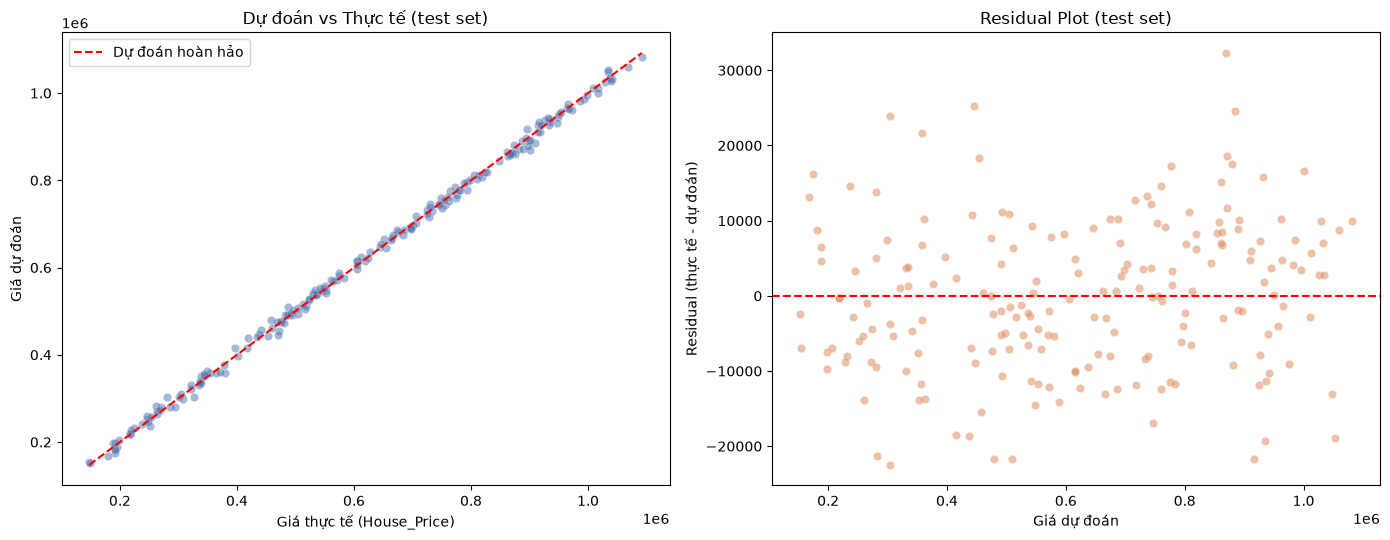

In [23]:
# 11. VISUALIZATION

residuals = y_test - y_pred
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
 
axes[0].scatter(y_test, y_pred, alpha=0.5, color="#4C72B0", edgecolor="white", linewidth=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, "r--", label="Dự đoán hoàn hảo")
axes[0].set_xlabel("Giá thực tế (House_Price)")
axes[0].set_ylabel("Giá dự đoán")
axes[0].set_title("Dự đoán vs Thực tế (test set)")
axes[0].legend()
 
axes[1].scatter(y_pred, residuals, alpha=0.5, color="#DD8452", edgecolor="white", linewidth=0.3)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Giá dự đoán")
axes[1].set_ylabel("Residual (thực tế - dự đoán)")
axes[1].set_title("Residual Plot (test set)")
 
plt.tight_layout()
plt.show()
plt.close()


In [28]:
# 12. FINAL EVALUATION & CONCLUSION

overfit_gap = results[best_name] - r2
 
print(f"""
Tổng kết:
  - Mô hình được chọn (dựa trên CV)      : {best_name}
  - CV R^2 trên train                    : {results[best_name]:.6f}
  - Test R^2 (chạm test đúng 1 lần)      : {r2:.6f}
  - Test RMSE                            : {rmse:,.2f}
  - Test MAE                             : {mae:,.2f}
  - Chênh lệch CV R^2 vs Test R^2        : {overfit_gap:.6f}
""")


Tổng kết:
  - Mô hình được chọn (dựa trên CV)      : LinearRegression
  - CV R^2 trên train                    : 0.998478
  - Test R^2 (chạm test đúng 1 lần)      : 0.998426
  - Test RMSE                            : 10,071.48
  - Test MAE                             : 8,174.58
  - Chênh lệch CV R^2 vs Test R^2        : 0.000051

